<a href="https://colab.research.google.com/github/flyingmandira-dotcom/Clinique-Agent-AI/blob/main/TradersSentimentAnalysisPrimetrade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

fg = pd.read_csv("/content/fear_greed_index.csv")
tr = pd.read_csv("/content/historical_data (1).csv")

print(fg.head())
print(fg.dtypes)
print(tr.head())
print(tr.dtypes)
print(tr.isna().sum())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
timestamp          int64
value              int64
classification    object
date              object
dtype: object
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16

/tmp/ipykernel_866/2204325682.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  tr = pd.read_csv("/content/historical_data (1).csv")


In [2]:
from scipy import stats

In [3]:
fg["date"] = pd.to_datetime(fg["date"]).dt.date
tr["date"] = pd.to_datetime(tr["Timestamp IST"], format="%d-%m-%Y %H:%M").dt.date

df = tr.merge(fg[["date", "value", "classification"]], on="date", how="left")
df = df.dropna(subset=["classification"])

In [4]:
df["sentiment"] = df["classification"].apply(
    lambda c: "Fear" if "Fear" in c else ("Greed" if "Greed" in c else "Neutral")
)

print(f"Loaded {len(df)} trades, {df['Account'].nunique()} accounts.\n")

Loaded 93180 trades, 16 accounts.



In [5]:
closed_trades = df[df["Closed PnL"] != 0]

print("Average Closed PnL per trade:")
print(df.groupby("sentiment")["Closed PnL"].mean(), "\n")

print("Win rate (% of closing trades that were profitable):")
print(closed_trades.groupby("sentiment")["Closed PnL"].apply(lambda x: (x > 0).mean() * 100), "\n")

Average Closed PnL per trade:
sentiment
Fear       77.860399
Greed      92.993946
Neutral    63.791293
Name: Closed PnL, dtype: float64 

Win rate (% of closing trades that were profitable):
sentiment
Fear       90.780587
Greed      87.613025
Neutral    91.605336
Name: Closed PnL, dtype: float64 



In [6]:
fear_pnl = closed_trades[closed_trades["sentiment"] == "Fear"]["Closed PnL"]
greed_pnl = closed_trades[closed_trades["sentiment"] == "Greed"]["Closed PnL"]
stat, p_value = stats.mannwhitneyu(fear_pnl, greed_pnl)
significant = "significant" if p_value < 0.05 else "NOT significant"
print(f"Fear vs Greed p-value: {p_value:.3f} -> {significant} (cutoff: 0.05)\n")

Fear vs Greed p-value: 0.000 -> significant (cutoff: 0.05)



In [7]:
print("Average position size (USD):")
print(df.groupby("sentiment")["Size USD"].mean(), "\n")

opens = df[df["Direction"].isin(["Open Long", "Open Short"])]
print("% of new positions that are LONG:")
print(opens.groupby("sentiment")["Direction"].apply(lambda x: (x == "Open Long").mean() * 100), "\n")

Average position size (USD):
sentiment
Fear       9416.624645
Greed      8764.977607
Neutral    7308.099761
Name: Size USD, dtype: float64 

% of new positions that are LONG:
sentiment
Fear       80.139112
Greed      59.737219
Neutral    72.103700
Name: Direction, dtype: float64 



In [8]:
pnl_by_account = df.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False)
top5_share = pnl_by_account.head(5).sum() / df["Closed PnL"].sum() * 100
print(f"Top 5 of {df['Account'].nunique()} accounts hold {top5_share:.0f}% of total PnL")

Top 5 of 16 accounts hold 79% of total PnL


In [9]:
import matplotlib.pyplot as plt

In [10]:
order = ["Fear", "Neutral", "Greed"]
colors = ["#E74C3C", "#95A5A6", "#2ECC71"]

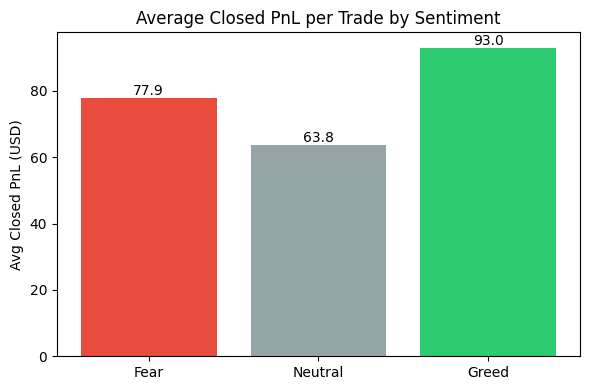

In [11]:
#chart1
avg_pnl = df.groupby("sentiment")["Closed PnL"].mean().reindex(order)
plt.figure(figsize=(6, 4))
plt.bar(avg_pnl.index, avg_pnl.values, color=colors)
for i, v in enumerate(avg_pnl.values):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.title("Average Closed PnL per Trade by Sentiment")
plt.ylabel("Avg Closed PnL (USD)")
plt.tight_layout()
plt.savefig("chart1_avg_pnl.png")
plt.show()
plt.close()

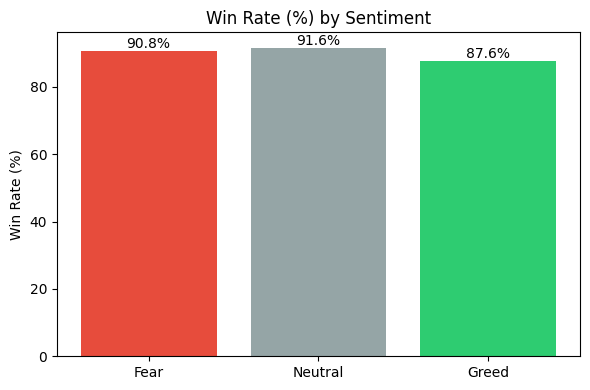

In [12]:
# Chart 2 — Win Rate by Sentiment
# NOTE: must use closed_trades (Closed PnL != 0), same filter as the printed table in cell 4.
# Using the full df here double-counts zero-PnL "open" rows as losses and deflates the rate.
win_rate = closed_trades.groupby("sentiment")["Closed PnL"].apply(lambda x: (x > 0).mean() * 100).reindex(order)
plt.figure(figsize=(6, 4))
plt.bar(win_rate.index, win_rate.values, color=colors)
for i, v in enumerate(win_rate.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.title("Win Rate (%) by Sentiment")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.savefig("chart2_win_rate.png")
plt.show()
plt.close()


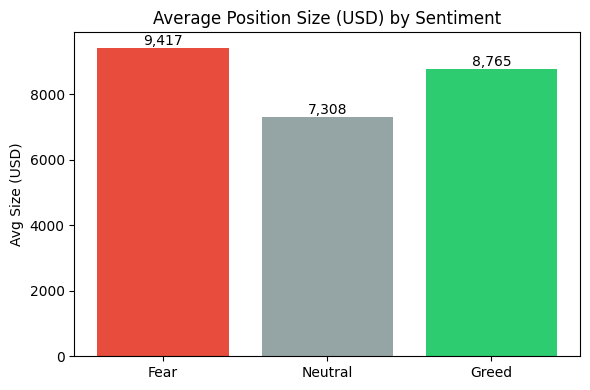

In [13]:
# Chart 3 — Avg Position Size by Sentiment
pos_size = df.groupby("sentiment")["Size USD"].mean().reindex(order)
plt.figure(figsize=(6, 4))
plt.bar(pos_size.index, pos_size.values, color=colors)
for i, v in enumerate(pos_size.values):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.title("Average Position Size (USD) by Sentiment")
plt.ylabel("Avg Size (USD)")
plt.tight_layout()
plt.savefig("chart3_pos_size.png")
plt.show()
plt.close()

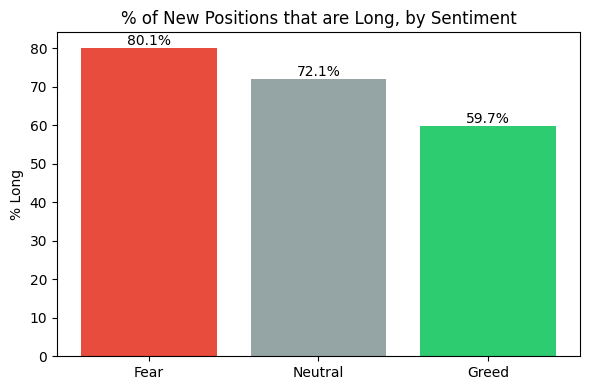

In [14]:
# Chart 4 — % of New Positions that are Long, by Sentiment
long_pct = opens.groupby("sentiment")["Direction"].apply(lambda x: (x == "Open Long").mean() * 100).reindex(order)
plt.figure(figsize=(6, 4))
plt.bar(long_pct.index, long_pct.values, color=colors)
for i, v in enumerate(long_pct.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.title("% of New Positions that are Long, by Sentiment")
plt.ylabel("% Long")
plt.tight_layout()
plt.savefig("chart4_long_pct.png")
plt.show()
plt.close()

In [15]:
# Sanity check — chart values must match the printed table values (cells 4 & 6)
# before anything gets saved into the report. Fails loudly instead of silently drifting.
import numpy as np

table_avg_pnl = df.groupby("sentiment")["Closed PnL"].mean().reindex(order)
table_win_rate = closed_trades.groupby("sentiment")["Closed PnL"].apply(lambda x: (x > 0).mean() * 100).reindex(order)
table_pos_size = df.groupby("sentiment")["Size USD"].mean().reindex(order)
table_long_pct = opens.groupby("sentiment")["Direction"].apply(lambda x: (x == "Open Long").mean() * 100).reindex(order)

checks = {
    "avg_pnl": (avg_pnl, table_avg_pnl),
    "win_rate": (win_rate, table_win_rate),
    "pos_size": (pos_size, table_pos_size),
    "long_pct": (long_pct, table_long_pct),
}

all_ok = True
for name, (chart_vals, table_vals) in checks.items():
    if not np.allclose(chart_vals.values, table_vals.values, atol=0.05):
        all_ok = False
        print(f"MISMATCH in {name}:")
        print(f"  chart: {chart_vals.to_dict()}")
        print(f"  table: {table_vals.to_dict()}")

if all_ok:
    print("All chart values match their table values. Safe to use in the report.")
else:
    raise AssertionError("Chart and table values diverge — do not use these charts until fixed.")


All chart values match their table values. Safe to use in the report.


In [16]:
print("\nSaved 4 charts: chart1_avg_pnl.png, chart2_win_rate.png, "
      "chart3_position_size.png, chart4_long_short_bias.png")


Saved 4 charts: chart1_avg_pnl.png, chart2_win_rate.png, chart3_position_size.png, chart4_long_short_bias.png


In [17]:
per_account_avg = df.groupby(["Account", "sentiment"])["Closed PnL"].mean().unstack()
print(per_account_avg.mean())   # average of account-level averages, not one big pooled average

sentiment
Fear       126.421959
Greed      111.827819
Neutral    175.652807
dtype: float64


In [18]:
closed_trades.groupby("sentiment")["Closed PnL"].median()

,Closed PnL
sentiment,
Fear,9.409950
Greed,12.598180
Neutral,9.104889
